Part A - Vectorized Programming with NumPy
Task 1 - Arrays, Statistics, and Indexing
● Generate Array A with 100 random integers. Set a random seed for reproducibility.
● Use NumPy functions to find min, max, median, mean, and standard deviation of Array A.
● Generate Array B with exactly 100 values using np.arange().
● Implement np.zeros() and np.ones(). Display shape and data type.
● Implement np.linspace(). Briefly state how it differs from np.arange().
● Create one 2D and one 3D array. Show shape, ndim, indexing, rows, columns, and slicing.
● Use reshape() to create a matrix, then flatten it back to 1D.

In [20]:
import numpy as np

np.random.seed(42)
A = np.random.randint(1, 100, 100)

print("Min:", A.min())
print("Max:", A.max())
print("Median:", np.median(A))
print("Mean:", A.mean())
print("Std:", A.std())

B = np.arange(100)

zeros = np.zeros((3, 3))
ones = np.ones((3, 3))
print(zeros.shape, zeros.dtype)
print(ones.shape, ones.dtype)

lin = np.linspace(0, 10, 5)
print(lin)
# linspace = fixed number of points; arange = fixed step size

arr2d = np.array([[1, 2, 3], [4, 5, 6]])
print(arr2d.shape, arr2d.ndim)
print(arr2d[0])       # row
print(arr2d[:, 1])    # column

arr3d = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])
print(arr3d.shape, arr3d.ndim)

matrix = np.arange(12).reshape(3, 4)
flat = matrix.flatten()
print(matrix)
print(flat)

Min: 2
Max: 95
Median: 53.5
Mean: 50.69
Std: 28.811350193977376
(3, 3) float64
(3, 3) float64
[ 0.   2.5  5.   7.5 10. ]
(2, 3) 2
[1 2 3]
[2 5]
(2, 2, 2) 3
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[ 0  1  2  3  4  5  6  7  8  9 10 11]


Task 2 - Vectorized Arithmetic and Linear Algebra
● Create two matrices. Perform addition, element-wise multiplication, and matrix multiplication using @
or np.matmul().
● For a square matrix, find its transpose and determinant.
● If invertible, find the inverse and verify A @ A^-1 using np.allclose().
● Use vectorized NumPy operations; avoid explicit Python loops.

In [21]:
import numpy as np

M1 = np.array([[1, 2], [3, 4]])
M2 = np.array([[5, 6], [7, 8]])

print("Add:\n", M1 + M2)
print("Multiply (element-wise):\n", M1 * M2)
print("Matrix multiply:\n", M1 @ M2)

print("Transpose:\n", M1.T)
det = np.linalg.det(M1)
print("Determinant:", det)

inv = np.linalg.inv(M1)
print("Inverse:\n", inv)
print("Check:", np.allclose(M1 @ inv, np.eye(2)))

Add:
 [[ 6  8]
 [10 12]]
Multiply (element-wise):
 [[ 5 12]
 [21 32]]
Matrix multiply:
 [[19 22]
 [43 50]]
Transpose:
 [[1 3]
 [2 4]]
Determinant: -2.0000000000000004
Inverse:
 [[-2.   1. ]
 [ 1.5 -0.5]]
Check: True


Task 3 - Normal Distribution and Histogram
● Generate at least 1,000 values from a normal distribution. State the chosen mean and standard
deviation.
● Find the sample mean and sample standard deviation. Compare them with the chosen values.
● Plot a histogram with it.

Sample mean: 50.500486464480694
Sample std: 10.0202284479383


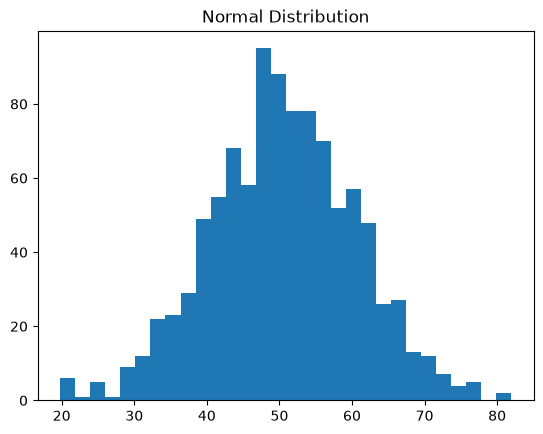

In [23]:
import os
os.makedirs("figures", exist_ok=True)
os.makedirs("data", exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt

mean, std = 50, 10
data = np.random.normal(mean, std, 1000)

print("Sample mean:", data.mean())
print("Sample std:", data.std())

plt.hist(data, bins=30)
plt.title("Normal Distribution")
plt.savefig("figures/histogram.png")
plt.show()

Part B - Data Wrangling with Pandas: Titanic Dataset
Task 4 - Load and Inspect Data
● Load train.csv. Implement head(), tail(), shape, columns, info(), and describe().
● Use loc and iloc to select rows/columns. Give one example of each and state the difference.

In [25]:
import os
import pandas as pd

os.makedirs("data", exist_ok=True)

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.to_csv("data/train.csv", index=False)

print(df.shape)
print(df.head())

import pandas as pd

df = pd.read_csv("data/train.csv")

print(df.head())
print(df.tail())
print(df.shape)
print(df.columns)
df.info()
print(df.describe())

print(df.loc[0:5, ["Name", "Age"]])   # label-based
print(df.iloc[0:5, 0:3])              # position-based

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

Task 5 - Filtering and Querying
Use Boolean indexing and/or query() to answer:
● Male passengers older than 50: how many?
● Female first-class passengers: how many, and what percentage survived?
● Age 20-40, Fare above overall median, and survived: how many?
● Travelling alone (SibSp=0, Parch=0), age < 30, and did not survive: how many?
● Embarked='S', Pclass 2 or 3, and Fare above Southampton median: how many?

In [26]:
import pandas as pd

df = pd.read_csv("data/train.csv")

print(len(df[(df.Sex == "male") & (df.Age > 50)]))

fc = df[(df.Sex == "female") & (df.Pclass == 1)]
print(len(fc), fc.Survived.mean() * 100)

med_fare = df.Fare.median()
print(len(df[(df.Age.between(20, 40)) & (df.Fare > med_fare) & (df.Survived == 1)]))

print(len(df[(df.SibSp == 0) & (df.Parch == 0) & (df.Age < 30) & (df.Survived == 0)]))

s_med = df[df.Embarked == "S"].Fare.median()
print(len(df[(df.Embarked == "S") & (df.Pclass.isin([2, 3])) & (df.Fare > s_med)]))

47
94 96.80851063829788
104
141
193


Task 6 - groupby() and Aggregation
● Survival rate by Sex.
● Survival rate by Pclass.
● Average Age and Fare by Pclass.
● Passenger count and survival rate by Sex-Pclass.
● Passenger count, average Fare, and survival rate by Embarked.

In [27]:
import pandas as pd

df = pd.read_csv("data/train.csv")

print(df.groupby("Sex").Survived.mean())
print(df.groupby("Pclass").Survived.mean())
print(df.groupby("Pclass")[["Age", "Fare"]].mean())
print(df.groupby(["Sex", "Pclass"]).Survived.agg(["count", "mean"]))
print(df.groupby("Embarked").agg(count=("PassengerId","count"), fare=("Fare","mean"), survival=("Survived","mean")))

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
              Age       Fare
Pclass                      
1       38.233441  84.154687
2       29.877630  20.662183
3       25.140620  13.675550
               count      mean
Sex    Pclass                 
female 1          94  0.968085
       2          76  0.921053
       3         144  0.500000
male   1         122  0.368852
       2         108  0.157407
       3         347  0.135447
          count       fare  survival
Embarked                            
C           168  59.954144  0.553571
Q            77  13.276030  0.389610
S           644  27.079812  0.336957


Task 7 - Missing Values and Fare Outliers
● Find the missing-value count and percentage for every column. Plot missing counts as a bar chart.
● Fill missing Age values with the mean Age. Show missing counts before and after.
● Try to fill NaN values by imputing using: mean, median, mode, random value
● For Fare, calculate Q1, Q3, IQR, 1.5xIQR bounds, and count the outliers.

Age         177
Cabin       687
Embarked      2
dtype: int64


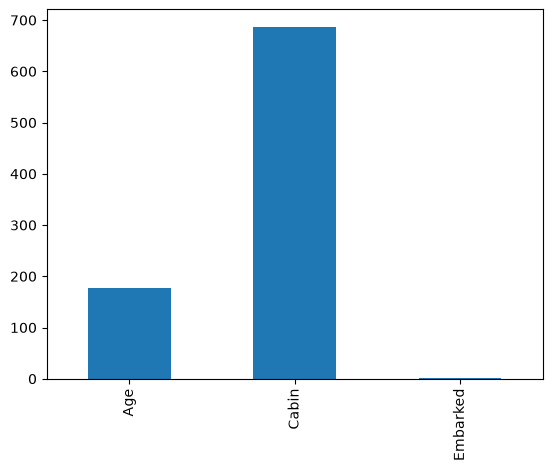

Before: 177
After: 0
116


In [28]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/train.csv")

missing = df.isnull().sum()
print(missing[missing > 0])

missing[missing > 0].plot(kind="bar")
plt.savefig("figures/missing.png")
plt.show()

print("Before:", df.Age.isnull().sum())
df.Age = df.Age.fillna(df.Age.mean())
print("After:", df.Age.isnull().sum())

Q1 = df.Fare.quantile(0.25)
Q3 = df.Fare.quantile(0.75)
IQR = Q3 - Q1
low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df.Fare < low) | (df.Fare > high)]
print(len(outliers))

Task 8 - Features and Pivot Table
● Create FamilySize = SibSp + Parch + 1 and IsAlone = 1 when FamilySize = 1.
● Create a pivot table: rows=Sex, columns=Pclass, values=mean Survived. Find the highest and lowest
groups.

In [29]:
import pandas as pd

df = pd.read_csv("data/train.csv")

df["FamilySize"] = df.SibSp + df.Parch + 1
df["IsAlone"] = (df.FamilySize == 1).astype(int)

pivot = df.pivot_table(values="Survived", index="Sex", columns="Pclass", aggfunc="mean")
print(pivot)

Pclass         1         2         3
Sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447


Task 9 - Visualizations and Observations
● Plot a correlation heatmap for relevant numerical columns. Note the strongest positive and negative
relationships.
● Plot the survival rate by Sex and report the male/female survival rates.
● Plot Age vs Fare and distinguish Survived=0 and Survived=1.
● Write 5-7 short observations supported by your numerical results or plots.

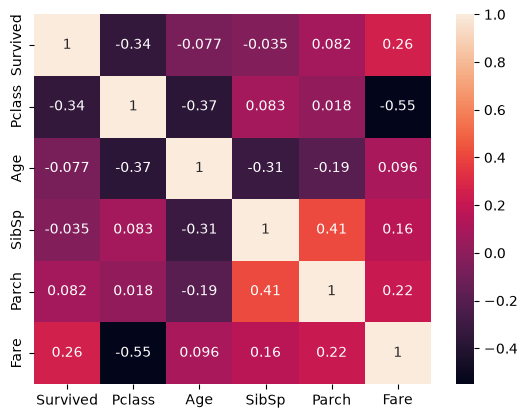

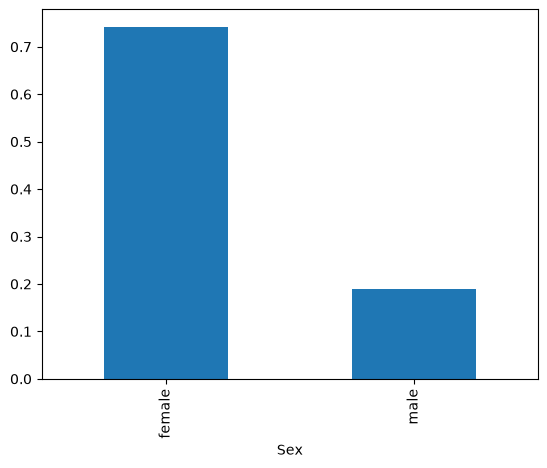

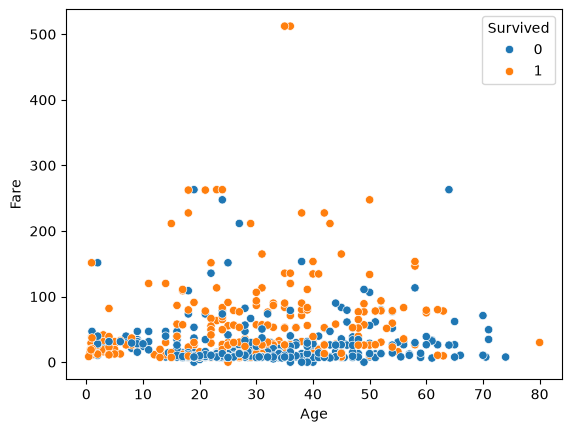

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/train.csv")

corr = df[["Survived","Pclass","Age","SibSp","Parch","Fare"]].corr()
sns.heatmap(corr, annot=True)
plt.savefig("figures/heatmap.png")
plt.show()

df.groupby("Sex").Survived.mean().plot(kind="bar")
plt.savefig("figures/survival_by_sex.png")
plt.show()

sns.scatterplot(data=df, x="Age", y="Fare", hue="Survived")
plt.savefig("figures/age_vs_fare.png")
plt.show()